# 08c) Final Odd-Day Evaluation: TSI vs RGB Mask vs ACM vs MODIS Cloud Fraction

This notebook now uses the final evaluation products from the even-day-trained ERA5-Land temperature-bin RGB decision-tree rules.

Evaluation setup:
- Train: even calendar days, in notebook 05b.
- Evaluate: odd calendar days.
- RGB prediction: apply the trained temperature-bin rules to raw RGB pixels in the 10 km by 10 km box, then average the binary mask to cloud fraction.
- ACM comparison: average GOES ABI L2 ACM/BCM over the same 10 km by 10 km box.
- Reference: SAIL TSI cloud fraction matched to GOES timestamps.
- MODIS: daytime Terra/Aqua cloud-mask granules are extracted separately to CSV, then matched to the same GOES/TSI timeline.

Domain:
- center: `38.96121, -106.99264`
- lat bounds: `38.916171` to `39.006249`
- lon bounds: `-107.050328` to `-106.934952`

Key result, cloud fraction estimate minus TSI:

| Estimate | n | Bias | MAE | RMSE | Corr |
|---|---:|---:|---:|---:|---:|
| RGB mask | 33,399 | +0.025 | 0.129 | 0.229 | 0.863 |
| ACM | 33,191 | +0.149 | 0.190 | 0.322 | 0.781 |

ACM is substantially more positively biased than the new RGB mask over this domain.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

ROOT = Path('/glade/u/home/cdalden/goes_work/analysis')
COMPARE_CSV = ROOT / 'tsi_rgb_tempbin_raw_odd_day_cloud_fraction_vs_tsi_acm.csv'
METRICS_CSV = ROOT / 'tsi_rgb_tempbin_raw_odd_day_cloud_fraction_metrics.csv'
MONTHLY_METRICS_CSV = ROOT / 'tsi_rgb_tempbin_raw_odd_day_cloud_fraction_monthly_metrics.csv'
SEASONAL_METRICS_CSV = ROOT / 'tsi_rgb_tempbin_raw_odd_day_cloud_fraction_seasonal_metrics.csv'
MASK_NC = ROOT / 'tsi_rgb_tempbin_raw_odd_day_cloud_mask_10km.nc'
MODIS_CSV = ROOT / 'output_08c/colorado_modis_daytime_mosaics.csv'
MODIS_COMPARE_CSV = ROOT / 'output_08c/colorado_modis_daytime_cloud_fraction_vs_tsi_rgb_acm.csv'

DATE_SELECT = pd.Timestamp('2023-05-15')

for path in [COMPARE_CSV, METRICS_CSV, MONTHLY_METRICS_CSV, SEASONAL_METRICS_CSV, MASK_NC, MODIS_CSV]:
    if not path.exists():
        raise FileNotFoundError(path)


## Load Final Evaluation Tables

In [13]:
compare_df = pd.read_csv(COMPARE_CSV, parse_dates=['time'])
metrics_df = pd.read_csv(METRICS_CSV)
monthly_metrics = pd.read_csv(MONTHLY_METRICS_CSV)
seasonal_metrics = pd.read_csv(SEASONAL_METRICS_CSV)
modis_df = pd.read_csv(MODIS_CSV, parse_dates=['date', 't', 'time_start', 'time_end'])
modis_df = modis_df.loc[modis_df['full_geolocation_coverage'] & modis_df['modis_cloud_fraction'].notna()].copy()

season_map = {
    12: 'DJF', 1: 'DJF', 2: 'DJF',
    3: 'MAM', 4: 'MAM', 5: 'MAM',
    6: 'JJA', 7: 'JJA', 8: 'JJA',
    9: 'SON', 10: 'SON', 11: 'SON',
}

compare_df['date'] = compare_df['time'].dt.normalize()
compare_df['month'] = compare_df['time'].dt.to_period('M').astype(str)
compare_df['season'] = compare_df['time'].dt.month.map(season_map)
compare_df['rgb_minus_tsi'] = compare_df['goes_rgb_cloud_fraction'] - compare_df['tsi_frac']
compare_df['acm_minus_tsi'] = compare_df['acm_cloud_fraction'] - compare_df['tsi_frac']

modis_df = modis_df.sort_values('t').reset_index(drop=True)
modis_compare_df = pd.merge_asof(
    modis_df,
    compare_df[['time', 'tsi_frac', 'goes_rgb_cloud_fraction', 'acm_cloud_fraction']]
        .rename(columns={'time': 't'})
        .sort_values('t'),
    on='t',
    direction='nearest',
    tolerance=pd.Timedelta('3min'),
)
modis_compare_df['season'] = modis_compare_df['t'].dt.month.map(season_map)
modis_compare_df['month'] = modis_compare_df['t'].dt.to_period('M').astype(str)
modis_compare_df['modis_minus_tsi'] = modis_compare_df['modis_cloud_fraction'] - modis_compare_df['tsi_frac']
modis_compare_df['modis_minus_rgb'] = modis_compare_df['modis_cloud_fraction'] - modis_compare_df['goes_rgb_cloud_fraction']
modis_compare_df['modis_minus_acm'] = modis_compare_df['modis_cloud_fraction'] - modis_compare_df['acm_cloud_fraction']
modis_compare_df.to_csv(MODIS_COMPARE_CSV, index=False)

print(f'Rows: {len(compare_df):,}')
print(f'Time range: {compare_df.time.min()} to {compare_df.time.max()}')
print(f'Rows with TSI: {compare_df.tsi_frac.notna().sum():,}')
print(f'Rows with ACM: {compare_df.acm_cloud_fraction.notna().sum():,}')
print(f'Rows with MODIS daytime passes: {len(modis_df):,}')
print(f'MODIS matched to GOES/TSI rows: {modis_compare_df.tsi_frac.notna().sum():,}')
print(f'MODIS comparison file: {MODIS_COMPARE_CSV}')

summary_rows = []
for label, column in [
    ('TSI', 'tsi_frac'),
    ('GOES RGB', 'goes_rgb_cloud_fraction'),
    ('GOES ACM', 'acm_cloud_fraction'),
]:
    valid = modis_compare_df[['modis_cloud_fraction', column]].dropna()
    if valid.empty:
        summary_rows.append({
            'reference': label,
            'n': 0,
            'bias': np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'corr': np.nan,
        })
        continue
    error = valid['modis_cloud_fraction'] - valid[column]
    summary_rows.append({
        'reference': label,
        'n': len(valid),
        'bias': float(error.mean()),
        'mae': float(np.abs(error).mean()),
        'rmse': float(np.sqrt((error ** 2).mean())),
        'corr': float(valid['modis_cloud_fraction'].corr(valid[column])),
        'tsi_mean': float(valid[column].mean()),
        'estimate_mean': float(valid['modis_cloud_fraction'].mean()),
    })
modis_summary = pd.DataFrame(summary_rows)
modis_summary


Rows: 88,704
Time range: 2021-10-01 00:02:30 to 2023-06-29 23:57:30
Rows with TSI: 33,458
Rows with ACM: 88,262
Rows with MODIS daytime passes: 1,338
MODIS matched to GOES/TSI rows: 596
MODIS comparison file: /glade/u/home/cdalden/goes_work/analysis/output_08c/colorado_modis_daytime_cloud_fraction_vs_tsi_rgb_acm.csv


,reference,n,bias,mae,rmse,corr,tsi_mean,estimate_mean
0,TSI,596,0.161899,0.179652,0.295901,0.816242,0.450084,0.611984
1,GOES RGB,643,0.128414,0.160421,0.290456,0.824062,0.477894,0.606307
2,GOES ACM,639,0.017747,0.140249,0.258380,0.818411,0.588811,0.606558


## Overall Metrics

In [14]:
goes_overall_metrics = metrics_df.loc[metrics_df['metric_set'].eq('all_matched_tsi')].copy()
modis_overall_metrics = modis_summary.loc[modis_summary['reference'].eq('TSI')].copy()
modis_overall_metrics['estimate'] = 'MODIS daytime'
modis_overall_metrics = modis_overall_metrics[[
    'estimate', 'n', 'bias', 'mae', 'rmse', 'corr', 'tsi_mean', 'estimate_mean'
]].rename(columns={'corr': 'correlation'})
overall_metrics = pd.concat([
    goes_overall_metrics[['estimate', 'n', 'bias', 'mae', 'rmse', 'correlation', 'tsi_mean', 'estimate_mean']],
    modis_overall_metrics,
], ignore_index=True)
overall_metrics

,estimate,n,bias,mae,rmse,correlation,tsi_mean,estimate_mean
0,goes_rgb_cloud_fraction,33399,0.025368,0.129033,0.228861,0.862845,0.406100,0.431469
1,acm_cloud_fraction,33191,0.149141,0.190425,0.322486,0.780577,0.406462,0.555602
2,MODIS daytime,596,0.161899,0.179652,0.295901,0.816242,0.450084,0.611984


## Seasonal Bias

In [15]:
def pivot_metrics(df, index_col):
    rows = []
    for value, group in df.groupby(index_col):
        row = {index_col: value}
        for _, r in group.iterrows():
            prefix = 'rgb' if r['estimate'] == 'goes_rgb_cloud_fraction' else 'acm'
            row[f'{prefix}_n'] = int(r['n'])
            row[f'{prefix}_bias'] = r['bias']
            row[f'{prefix}_mae'] = r['mae']
            row[f'{prefix}_rmse'] = r['rmse']
            row[f'{prefix}_corr'] = r['correlation']
        rows.append(row)
    return pd.DataFrame(rows)

season_order = ['DJF', 'MAM', 'JJA', 'SON']
seasonal_table = pivot_metrics(seasonal_metrics, 'season').set_index('season').loc[season_order].reset_index()
modis_seasonal_table = (
    modis_compare_df.dropna(subset=['modis_minus_tsi'])
    .groupby('season', observed=False)
    .apply(lambda g: pd.Series({
        'modis_n': len(g),
        'modis_bias': g['modis_minus_tsi'].mean(),
        'modis_mae': g['modis_minus_tsi'].abs().mean(),
        'modis_rmse': np.sqrt((g['modis_minus_tsi'] ** 2).mean()),
        'modis_corr': g['modis_cloud_fraction'].corr(g['tsi_frac']),
        'modis_tsi_mean': g['tsi_frac'].mean(),
        'modis_estimate_mean': g['modis_cloud_fraction'].mean(),
    }))
    .reindex(season_order)
    .reset_index()
)
seasonal_table = seasonal_table.merge(modis_seasonal_table, on='season', how='left')
seasonal_table

,season,rgb_n,rgb_bias,rgb_mae,rgb_rmse,rgb_corr,acm_n,acm_bias,acm_mae,acm_rmse,acm_corr,modis_n,modis_bias,modis_mae,modis_rmse,modis_corr,modis_tsi_mean,modis_estimate_mean
0,DJF,8333,0.033083,0.114703,0.225429,0.872254,8326,0.120281,0.169562,0.320412,0.784858,163.0,0.154838,0.162378,0.299414,0.838336,0.420489,0.575327
1,MAM,10917,0.069494,0.139823,0.245711,0.852016,10896,0.197407,0.227955,0.366239,0.717433,178.0,0.188471,0.195786,0.314906,0.801437,0.497653,0.686123
2,JJA,5631,-0.038484,0.138487,0.218834,0.869470,5611,0.089516,0.152955,0.245585,0.854568,103.0,0.035338,0.090535,0.143017,0.939836,0.505919,0.541257
3,SON,8518,0.003479,0.122973,0.215920,0.858157,8358,0.154995,0.187436,0.308820,0.801094,152.0,0.224117,0.239671,0.342334,0.762577,0.388280,0.612398


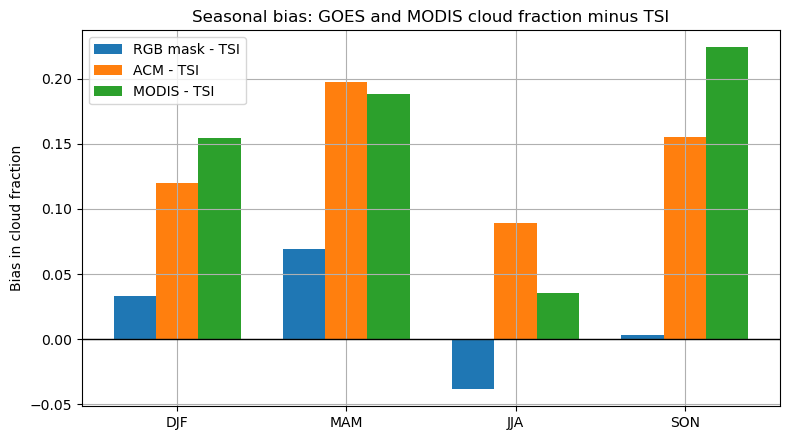

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(seasonal_table))
modis_seasonal_table = (
    modis_compare_df.dropna(subset=['modis_minus_tsi'])
    .groupby('season', observed=False)['modis_minus_tsi']
    .agg(['count', 'mean'])
    .reindex(season_order)
)
width = 0.25
ax.bar(x - width, seasonal_table['rgb_bias'], width, label='RGB mask - TSI')
ax.bar(x, seasonal_table['acm_bias'], width, label='ACM - TSI')
ax.bar(x + width, modis_seasonal_table['mean'], width, label='MODIS - TSI')
ax.axhline(0, color='k', lw=1)
ax.set_xticks(x)
ax.set_xticklabels(seasonal_table['season'])
ax.set_ylabel('Bias in cloud fraction')
ax.set_title('Seasonal bias: GOES and MODIS cloud fraction minus TSI')
ax.legend()
plt.tight_layout()

## Monthly Bias and Skill

In [17]:
monthly_table = pivot_metrics(monthly_metrics, 'month')
modis_monthly_table = (
    modis_compare_df.dropna(subset=['modis_minus_tsi'])
    .groupby('month', observed=False)
    .apply(lambda g: pd.Series({
        'modis_n': len(g),
        'modis_bias': g['modis_minus_tsi'].mean(),
        'modis_mae': g['modis_minus_tsi'].abs().mean(),
        'modis_rmse': np.sqrt((g['modis_minus_tsi'] ** 2).mean()),
        'modis_corr': g['modis_cloud_fraction'].corr(g['tsi_frac']),
        'modis_tsi_mean': g['tsi_frac'].mean(),
        'modis_estimate_mean': g['modis_cloud_fraction'].mean(),
    }))
    .reset_index()
)
monthly_table = monthly_table.merge(modis_monthly_table, on='month', how='left')
monthly_table

,month,rgb_n,rgb_bias,rgb_mae,rgb_rmse,rgb_corr,acm_n,acm_bias,acm_mae,acm_rmse,acm_corr,modis_n,modis_bias,modis_mae,modis_rmse,modis_corr,modis_tsi_mean,modis_estimate_mean
0,2021-10,1905,0.019701,0.136316,0.227522,0.849471,1902,0.209506,0.234699,0.352163,0.763277,36.0,0.198782,0.206657,0.289855,0.849589,0.447125,0.645906
1,2021-11,1572,-0.002642,0.091618,0.168410,0.905776,1571,0.218147,0.223956,0.356746,0.778288,29.0,0.343426,0.343426,0.444209,0.689103,0.304051,0.647477
2,2021-12,1677,-0.009977,0.100747,0.221163,0.880398,1675,0.086175,0.149759,0.300380,0.798252,34.0,0.214719,0.224686,0.373894,0.755971,0.444448,0.659167
3,2022-01,1736,0.048656,0.110860,0.221355,0.852977,1735,0.177065,0.204549,0.367243,0.725886,35.0,0.163988,0.171865,0.318693,0.816438,0.256459,0.420447
4,2022-02,1624,0.032832,0.078853,0.169793,0.926184,1624,0.070888,0.110452,0.232372,0.876027,29.0,0.069675,0.080445,0.170227,0.948249,0.328362,0.398038
5,2022-03,1918,0.130216,0.163259,0.281536,0.831071,1914,0.173882,0.206015,0.349814,0.761861,32.0,0.249626,0.271359,0.416877,0.670067,0.251742,0.501368
6,2022-04,1662,0.073326,0.117537,0.217171,0.875601,1660,0.129260,0.158727,0.296892,0.765672,21.0,0.161925,0.161963,0.277494,0.830909,0.658406,0.820331
7,2022-05,1915,0.066026,0.133645,0.218550,0.885489,1906,0.196892,0.218680,0.318750,0.790765,36.0,0.165896,0.169397,0.234488,0.908927,0.498816,0.664712
8,2022-06,1800,-0.002560,0.109699,0.180294,0.904365,1796,0.089323,0.137924,0.232936,0.875439,33.0,0.038071,0.059881,0.102330,0.972880,0.348928,0.386999
9,2022-07,1920,-0.044466,0.136500,0.214892,0.877897,1920,0.077874,0.147296,0.236089,0.861385,35.0,0.017809,0.086004,0.139186,0.937689,0.576755,0.594564


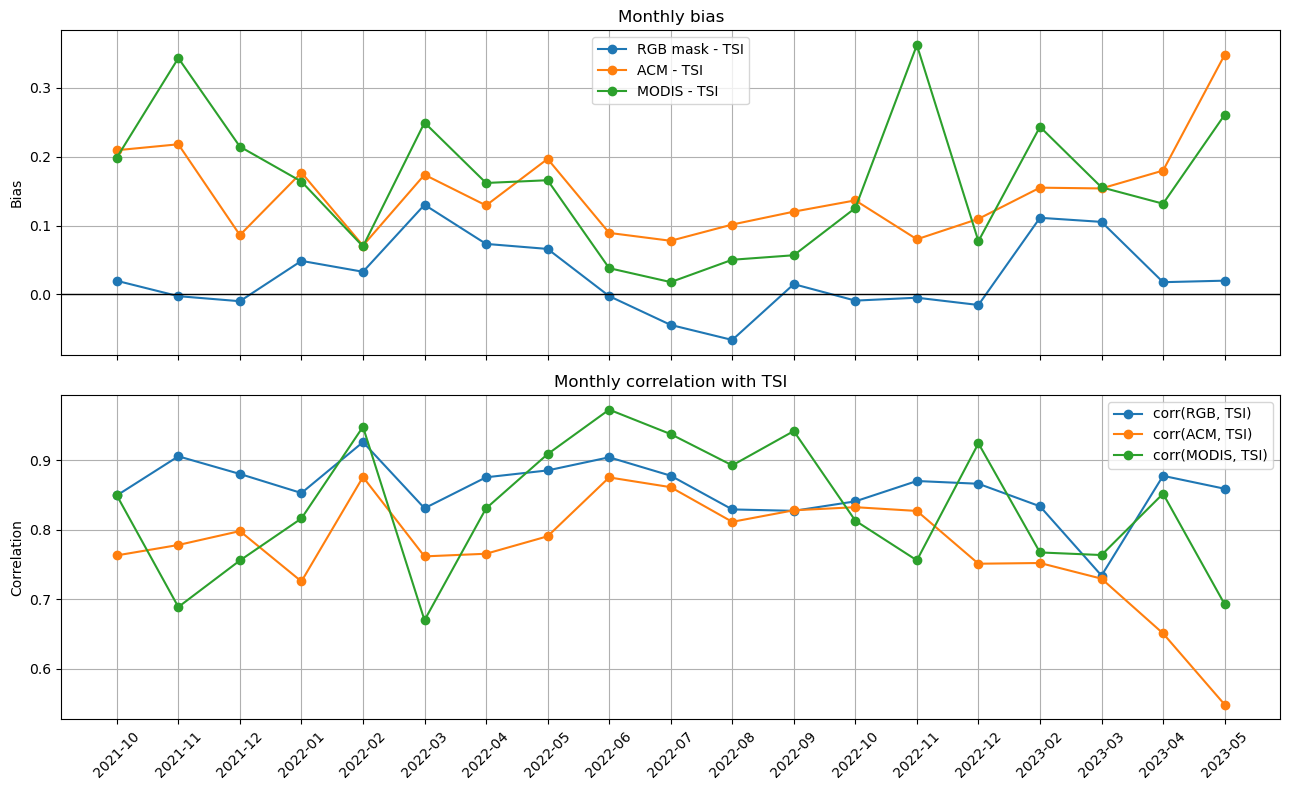

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(monthly_table['month'], monthly_table['rgb_bias'], marker='o', label='RGB mask - TSI')
axes[0].plot(monthly_table['month'], monthly_table['acm_bias'], marker='o', label='ACM - TSI')
axes[0].plot(monthly_table['month'], monthly_table['modis_bias'], marker='o', label='MODIS - TSI')
axes[0].axhline(0, color='k', lw=1)
axes[0].set_ylabel('Bias')
axes[0].set_title('Monthly bias')
axes[0].legend()

axes[1].plot(monthly_table['month'], monthly_table['rgb_corr'], marker='o', label='corr(RGB, TSI)')
axes[1].plot(monthly_table['month'], monthly_table['acm_corr'], marker='o', label='corr(ACM, TSI)')
axes[1].plot(monthly_table['month'], monthly_table['modis_corr'], marker='o', label='corr(MODIS, TSI)')
axes[1].set_ylabel('Correlation')
axes[1].set_title('Monthly correlation with TSI')
axes[1].legend()

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

## Seasonal Residual Histograms

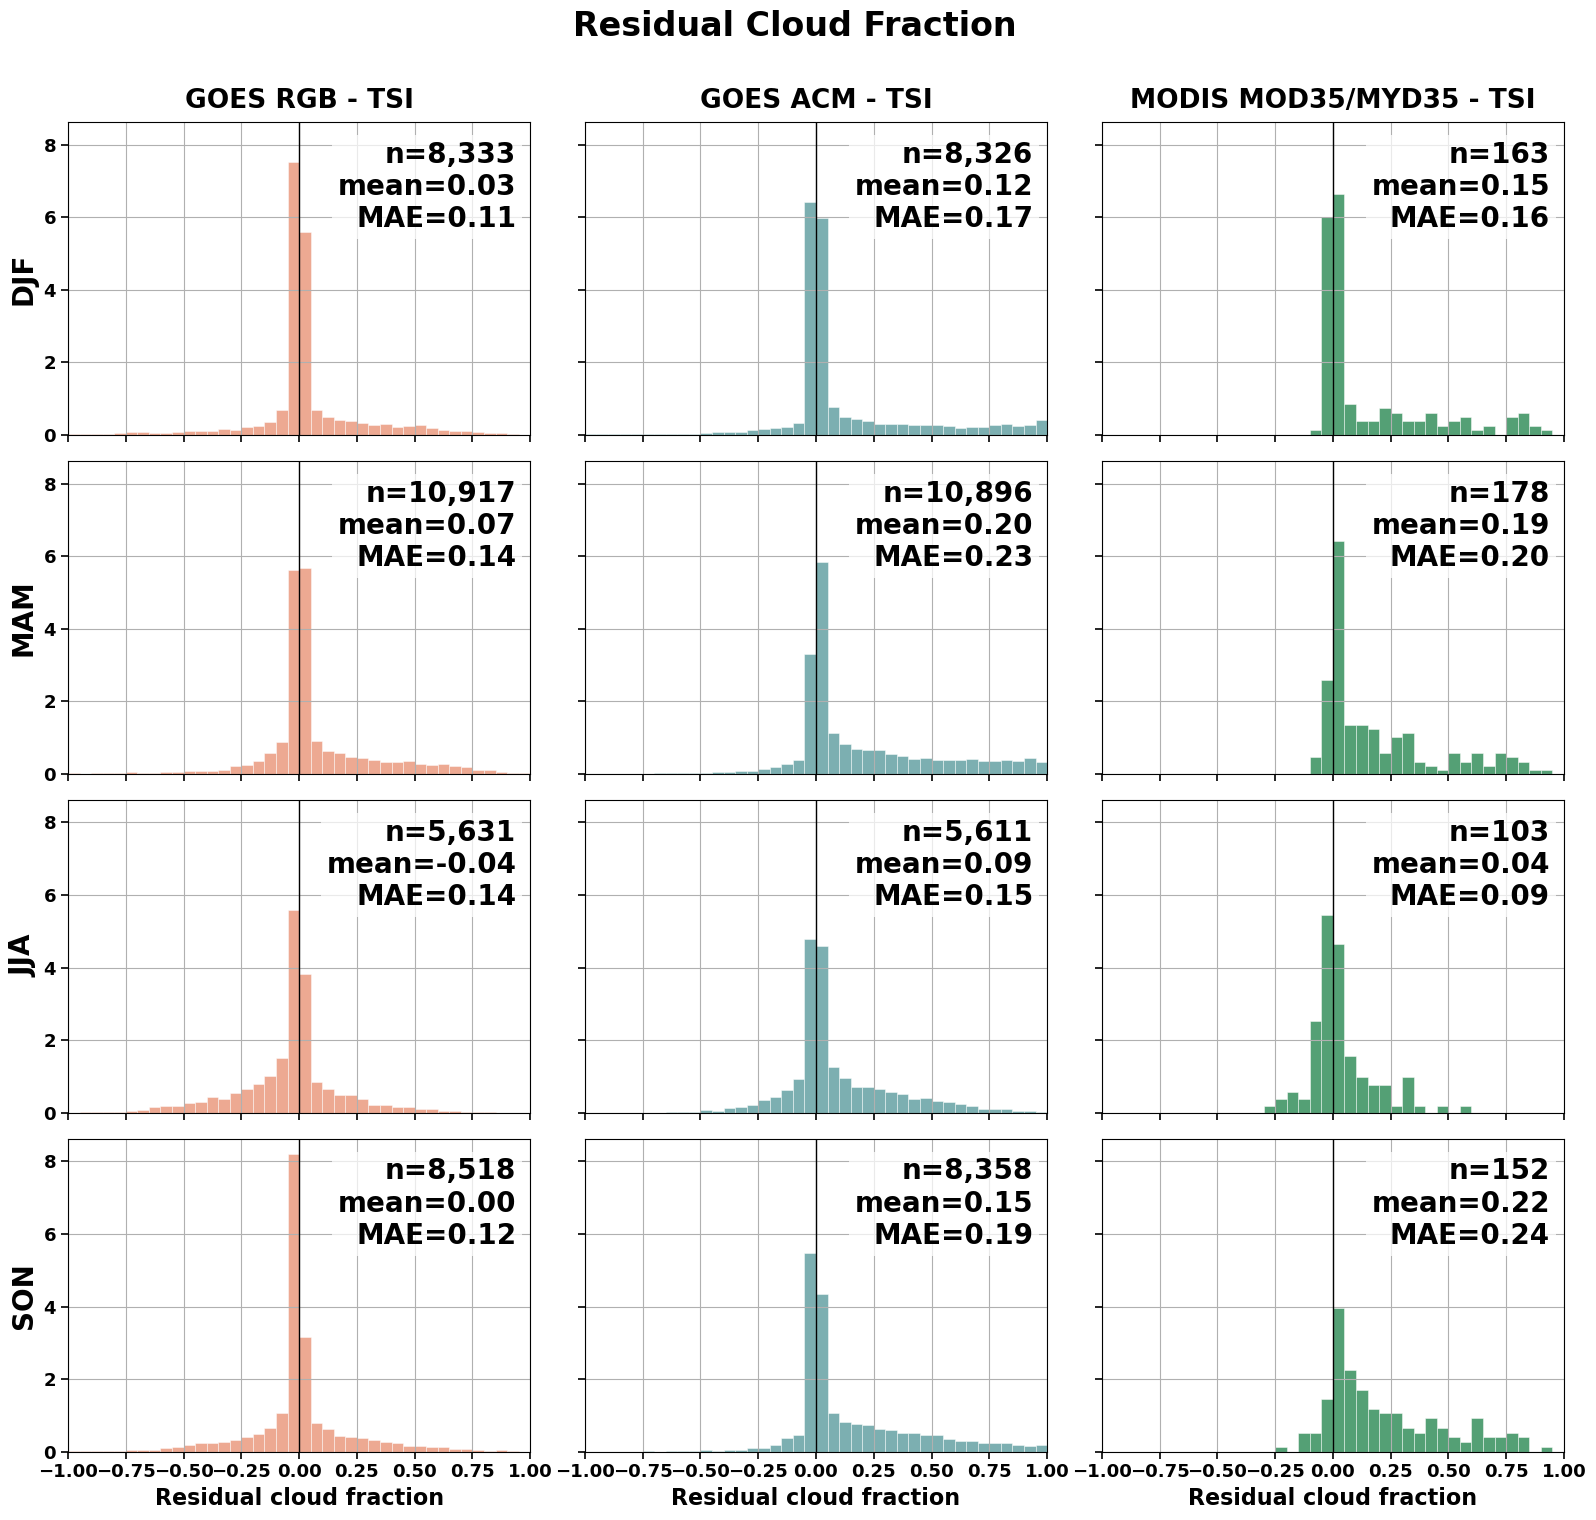

In [19]:
season_order = ['DJF', 'MAM', 'JJA', 'SON']
season_map = {
    12: 'DJF', 1: 'DJF', 2: 'DJF',
    3: 'MAM', 4: 'MAM', 5: 'MAM',
    6: 'JJA', 7: 'JJA', 8: 'JJA',
    9: 'SON', 10: 'SON', 11: 'SON',
}
column_specs = [
    ('GOES RGB - TSI', 'rgb_minus_tsi', 'darksalmon'),
    ('GOES ACM - TSI', 'acm_minus_tsi', 'cadetblue'),
    ('MODIS MOD35/MYD35 - TSI', 'modis_minus_tsi', 'seagreen'),
]

residual_frames = []
modis_plot_df = modis_compare_df.copy()
if 'season' not in modis_plot_df.columns:
    modis_plot_df['season'] = modis_plot_df['t'].dt.month.map(season_map)

for label, residual_col, _ in column_specs:
    if residual_col == 'modis_minus_tsi':
        residual_df = modis_plot_df[['season', residual_col]].dropna().copy()
    else:
        residual_df = compare_df[['season', residual_col]].dropna().copy()
    residual_df = residual_df.rename(columns={residual_col: 'residual'})
    residual_df['series'] = label
    residual_frames.append(residual_df)

residual_df = pd.concat(residual_frames, ignore_index=True)
bins = np.linspace(-1, 1, 41)

fig, axes = plt.subplots(4, 3, figsize=(16, 15), sharex=True, sharey=True)
for row_index, season in enumerate(season_order):
    for col_index, (label, _, color) in enumerate(column_specs):
        ax = axes[row_index, col_index]
        subset = residual_df.loc[(residual_df['season'] == season) & (residual_df['series'] == label), 'residual'].dropna()
        ax.hist(subset, bins=bins, density=True, alpha=0.82, color=color, edgecolor='white', linewidth=0.4)
        ax.axvline(0, color='k', lw=1)
        ax.set_xlim(-1, 1)
        ax.tick_params(axis='both', labelsize=13, width=1.2, length=5)
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight('bold')
        if row_index == 0:
            ax.set_title(label, fontsize=19, fontweight='bold', pad=10)
        if col_index == 0:
            ax.set_ylabel(f'{season}', fontsize=20, fontweight='bold')
        if row_index == len(season_order) - 1:
            ax.set_xlabel('Residual cloud fraction', fontsize=16, fontweight='bold')
        ax.text(
            0.97,
            0.94,
            f'n={len(subset):,}\nmean={subset.mean():.2f}\nMAE={subset.abs().mean():.2f}' if len(subset) else 'n=0',
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=20,
            fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'),
        )

fig.suptitle('Residual Cloud Fraction', y=1.01, fontsize=24, fontweight='bold')
plt.tight_layout()


## Temperature-Bin Metrics (GOES only)

MODIS is not temperature-binned, so this section remains the GOES RGB vs ACM comparison by ERA5-Land temperature bin.

In [20]:
temp_bin_metrics = metrics_df.loc[metrics_df['metric_set'].str.startswith('eval_temp_bin=', na=False)].copy()
temp_bin_metrics['temp_bin'] = temp_bin_metrics['metric_set'].str.replace('eval_temp_bin=', '', regex=False)
temp_bin_table = pivot_metrics(temp_bin_metrics, 'temp_bin')
temp_bin_table

,temp_bin,rgb_n,rgb_bias,rgb_mae,rgb_rmse,rgb_corr,acm_n,acm_bias,acm_mae,acm_rmse,acm_corr
0,"[-10, 0)",12268,0.056181,0.118083,0.223975,0.881643,12237,0.131709,0.170088,0.308738,0.804561
1,"[-20, -10)",5100,0.017246,0.145278,0.266259,0.812916,5091,0.106299,0.171953,0.315523,0.776874
2,"[0, 10)",9931,0.025009,0.119326,0.207959,0.884229,9844,0.217542,0.236724,0.369550,0.740737
3,"[10, 20)",6100,-0.029223,0.153275,0.237088,0.842658,6019,0.108947,0.171674,0.268573,0.824405


## One-Day Diagnostic

,time,goes_rgb_cloud_fraction,cloud_pixel_count,valid_pixel_count,era5_land_t2m_c,original_temp_bin_10c,eval_temp_bin_10c,routed_to_nearest_trained_bin,rgb_file,tsi_frac,acm_cloud_fraction,acm_cloud_pixel_count,acm_valid_pixel_count,acm_file,date,month,season,rgb_minus_tsi,acm_minus_tsi
81792,2023-05-15 00:02:30,0.690476,58,84,6.349579,"[0, 10)","[0, 10)",False,/glade/u/home/cdalden/scratch/colorado/goes16/...,NaN,1.0,24.0,24.0,/glade/u/home/cdalden/scratch/colorado_acm/goe...,2023-05-15,2023-05,MAM,NaN,NaN
81793,2023-05-15 00:07:30,0.690476,58,84,6.180756,"[0, 10)","[0, 10)",False,/glade/u/home/cdalden/scratch/colorado/goes16/...,NaN,1.0,24.0,24.0,/glade/u/home/cdalden/scratch/colorado_acm/goe...,2023-05-15,2023-05,MAM,NaN,NaN
81794,2023-05-15 00:12:30,0.690476,58,84,6.011932,"[0, 10)","[0, 10)",False,/glade/u/home/cdalden/scratch/colorado/goes16/...,NaN,1.0,24.0,24.0,/glade/u/home/cdalden/scratch/colorado_acm/goe...,2023-05-15,2023-05,MAM,NaN,NaN
81795,2023-05-15 00:17:30,0.690476,58,84,5.843109,"[0, 10)","[0, 10)",False,/glade/u/home/cdalden/scratch/colorado/goes16/...,NaN,1.0,24.0,24.0,/glade/u/home/cdalden/scratch/colorado_acm/goe...,2023-05-15,2023-05,MAM,NaN,NaN
81796,2023-05-15 00:22:30,0.690476,58,84,5.674286,"[0, 10)","[0, 10)",False,/glade/u/home/cdalden/scratch/colorado/goes16/...,NaN,1.0,24.0,24.0,/glade/u/home/cdalden/scratch/colorado_acm/goe...,2023-05-15,2023-05,MAM,NaN,NaN


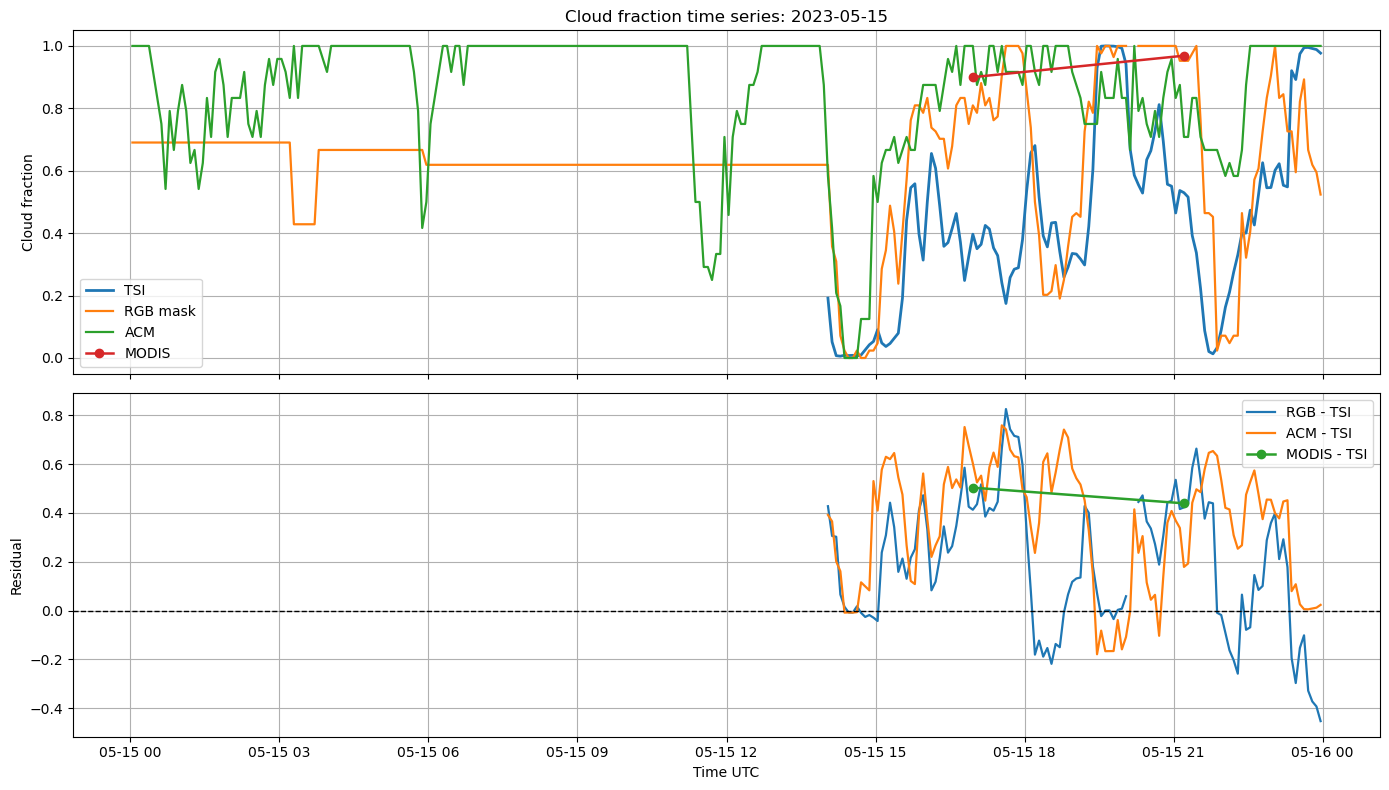

In [21]:
day_df = compare_df.loc[compare_df['date'].eq(DATE_SELECT.normalize())].sort_values('time').copy()
modis_day_df = modis_compare_df.loc[modis_compare_df['date'].eq(DATE_SELECT.normalize())].sort_values('t').copy()
if day_df.empty:
    raise ValueError(f'No odd-day eval rows found for {DATE_SELECT.date()}')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(day_df['time'], day_df['tsi_frac'], label='TSI', lw=2)
axes[0].plot(day_df['time'], day_df['goes_rgb_cloud_fraction'], label='RGB mask', lw=1.6)
axes[0].plot(day_df['time'], day_df['acm_cloud_fraction'], label='ACM', lw=1.6)
if not modis_day_df.empty:
    axes[0].plot(modis_day_df['t'], modis_day_df['modis_cloud_fraction'], label='MODIS', lw=1.8, marker='o')
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_ylabel('Cloud fraction')
axes[0].set_title(f'Cloud fraction time series: {DATE_SELECT.date()}')
axes[0].legend()

axes[1].plot(day_df['time'], day_df['rgb_minus_tsi'], label='RGB - TSI', lw=1.6)
axes[1].plot(day_df['time'], day_df['acm_minus_tsi'], label='ACM - TSI', lw=1.6)
if not modis_day_df.empty:
    axes[1].plot(modis_day_df['t'], modis_day_df['modis_minus_tsi'], label='MODIS - TSI', lw=1.8, marker='o')
axes[1].axhline(0, color='k', ls='--', lw=1)
axes[1].set_ylabel('Residual')
axes[1].set_xlabel('Time UTC')
axes[1].legend()

plt.tight_layout()
day_df.head()

## Binned Relationship to TSI

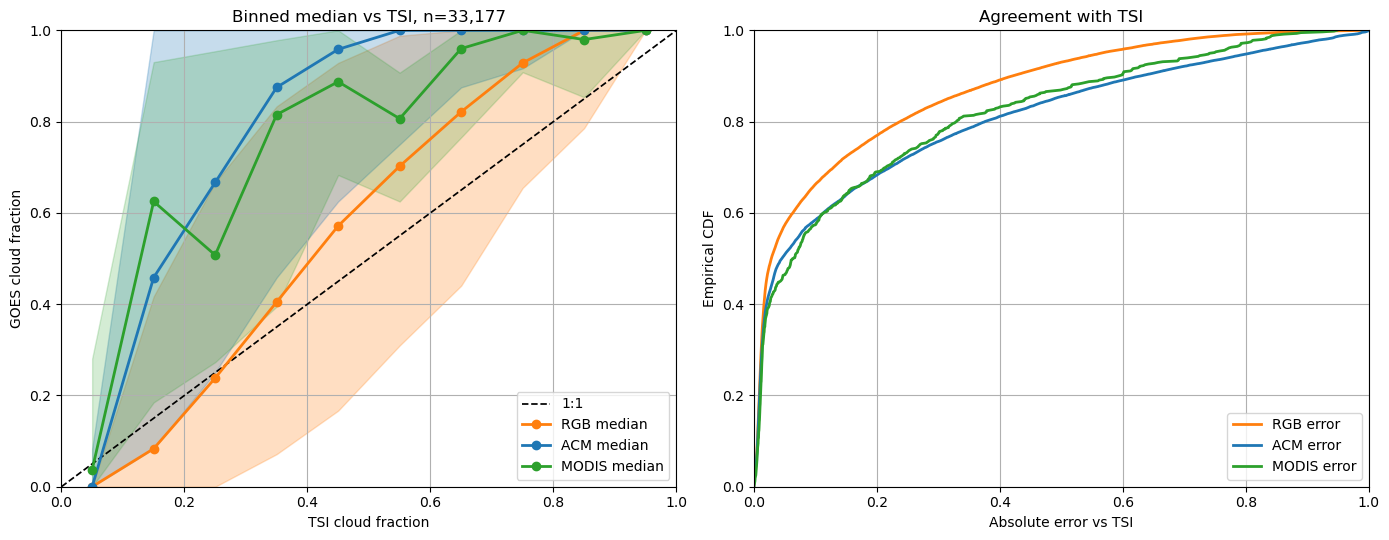

In [22]:
plot_df = compare_df.dropna(subset=['tsi_frac', 'goes_rgb_cloud_fraction', 'acm_cloud_fraction']).copy()
modis_plot_df = modis_compare_df.dropna(subset=['tsi_frac', 'modis_cloud_fraction']).copy()

bin_edges = np.linspace(0, 1, 11)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plot_df['tsi_bin'] = pd.cut(plot_df['tsi_frac'], bins=bin_edges, include_lowest=True)
modis_plot_df['tsi_bin'] = pd.cut(modis_plot_df['tsi_frac'], bins=bin_edges, include_lowest=True)

def binned_summary(df, value_col):
    grouped = df.groupby('tsi_bin', observed=False)[value_col]
    return pd.DataFrame({
        'median': grouped.median().to_numpy(),
        'q25': grouped.quantile(0.25).to_numpy(),
        'q75': grouped.quantile(0.75).to_numpy(),
        'count': grouped.count().to_numpy(),
    })

rgb_summary = binned_summary(plot_df, 'goes_rgb_cloud_fraction')
acm_summary = binned_summary(plot_df, 'acm_cloud_fraction')
modis_summary = binned_summary(modis_plot_df, 'modis_cloud_fraction')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.plot([0, 1], [0, 1], color='k', ls='--', lw=1.25, label='1:1')
ax.plot(bin_centers, rgb_summary['median'], color='tab:orange', lw=2, marker='o', label='RGB median')
ax.fill_between(bin_centers, rgb_summary['q25'], rgb_summary['q75'], color='tab:orange', alpha=0.25)
ax.plot(bin_centers, acm_summary['median'], color='tab:blue', lw=2, marker='o', label='ACM median')
ax.fill_between(bin_centers, acm_summary['q25'], acm_summary['q75'], color='tab:blue', alpha=0.25)
ax.plot(bin_centers, modis_summary['median'], color='tab:green', lw=2, marker='o', label='MODIS median')
ax.fill_between(bin_centers, modis_summary['q25'], modis_summary['q75'], color='tab:green', alpha=0.20)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('TSI cloud fraction')
ax.set_ylabel('GOES cloud fraction')
ax.set_title(f'Binned median vs TSI, n={len(plot_df):,}')
ax.legend()

ax = axes[1]
for err_col, label, color in [
    ('rgb_minus_tsi', 'RGB error', 'tab:orange'),
    ('acm_minus_tsi', 'ACM error', 'tab:blue'),
    ('modis_minus_tsi', 'MODIS error', 'tab:green'),
]:
    source_df = modis_plot_df if err_col == 'modis_minus_tsi' else plot_df
    vals = np.sort(np.abs(source_df[err_col].dropna().to_numpy()))
    ecdf = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, ecdf, lw=2, color=color, label=label)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Absolute error vs TSI')
ax.set_ylabel('Empirical CDF')
ax.set_title('Agreement with TSI')
ax.legend(loc='lower right')

plt.tight_layout()